# Failed tests

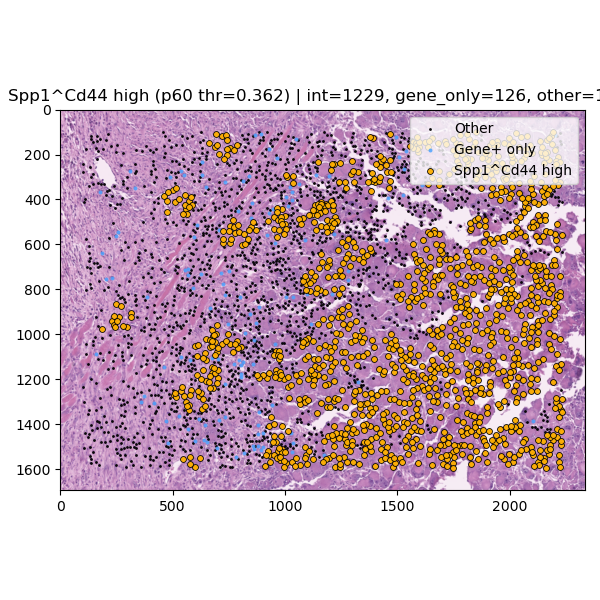

In [18]:
# --- plot (INT_HIGH drawn last so it visually dominates) ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_crop, origin="upper", extent=(0, w, h, 0))

if C_OTH.size:
    ax.scatter(C_OTH[:,0],  C_OTH[:,1],  s=4,  c="lightgrey", alpha=0.35, linewidths=0, label="Other")

if C_GENE.size:
    ax.scatter(C_GENE[:,0], C_GENE[:,1], s=8,  c="#4ea3ff",   alpha=0.85, linewidths=0, label="Gene+ only")

if C_INT.size:
    ax.scatter(C_INT[:,0],  C_INT[:,1],  s=18, c="#ffb000",   alpha=0.95, linewidth=0.6, edgecolor="black",
               label=f"{pair} high")

ax.set_xlim(0, w); ax.set_ylim(h, 0)
ax.set_title(f"{pair} high (p{int(pct*100)} thr={thr_int:.3g}) | "
             f"int={INT_HIGH.sum()}, gene_only={GENE_ONLY.sum()}, other={OTHER.sum()}")
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()

In [11]:
# If you want to see all the possible pairs lr.var_names

In [12]:

vals = lr[:, pair].X.toarray().ravel
# keep = lr[:,pair].X.toarray().ravel() > thresh
coords = lr.obsm["spatial"]
selected = np.zeros(coords.shape[0], dtype=bool) # place holder for the future lasso selection


In [ ]:
fig, ax = plt.subplots(figsize=(5,5))

sc.pl.spatial(
    lr,
    color=[pair],
    size=0.3,
    cmap="magma",
    library_id=lib_id,
    img_key="hires",
    show=True,
    ax=ax,
    alpha=0.5   
)



In [ ]:
'spatial' in lr.uns, list(lr.uns.get('spatial', {}).keys())

In [ ]:
lr.obsm["spatial"]

In [95]:
np.zeros(coords.shape[0], dtype=bool)

array([False, False, False, ..., False, False, False])

In [21]:
ST_sample.uns['spatial'].keys()

dict_keys(['F07839', 'F07840'])

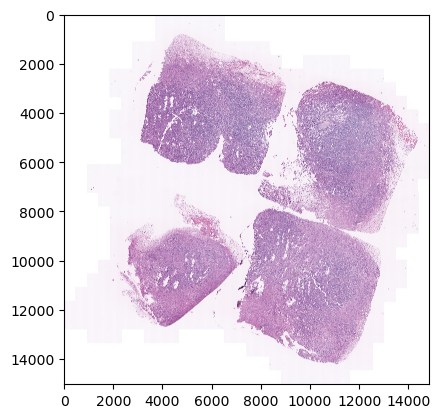

In [23]:
img = ST_sample.uns["spatial"]["F07840"]["images"]["hires"]

plt.imshow(img)
# plt.axis("off")
plt.show()

22

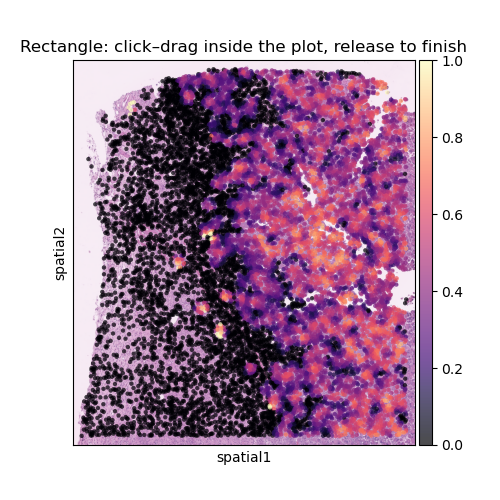

In [24]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

coords = np.asarray(lr.obsm["spatial"])  # (n,2)

fig, ax = plt.subplots(figsize=(5,5))
sq.pl.spatial_scatter(
    lr, color=pair, size=0.5, cmap="magma",
    library_id=lib_id, img_res_key="hires",
    crop_coord=crop, alpha=0.7, fig=fig, ax=ax, return_ax=False
)
ax.invert_yaxis()
ax.set_title("Rectangle: click–drag inside the plot, release to finish")

# Make sure the selector receives events (turn off pan/zoom)
tb = getattr(fig.canvas, "toolbar", None)
if tb is not None:
    tb.mode = ""

state = {"sel": np.zeros(coords.shape[0], bool), "box": None}

def onselect(eclick, erelease):
    if (eclick.xdata is None) or (eclick.ydata is None) or \
       (erelease.xdata is None) or (erelease.ydata is None):
        print("Selection cancelled (mouse outside axes). Try again.")
        return
    x0, y0 = float(eclick.xdata),  float(eclick.ydata)
    x1, y1 = float(erelease.xdata), float(erelease.ydata)
    xmin, xmax = sorted([x0, x1]); ymin, ymax = sorted([y0, y1])
    sel = (coords[:,0] >= xmin) & (coords[:,0] <= xmax) & \
          (coords[:,1] >= ymin) & (coords[:,1] <= ymax)
    state["sel"][:] = sel
    state["box"] = (xmin, ymin, xmax, ymax)
    print(f"Picked: {sel.sum()} / {len(coords)} within box {state['box']}")

# interactive=True keeps the rectangle visible and adjustable
rect_selector = RectangleSelector(
    ax, onselect,
    useblit=False, button=[1], interactive=True,
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2, alpha=0.9)
)

# Optional: press Enter to “finalize” and deactivate the tool
def on_key(event):
    if event.key == "enter":
        rect_selector.set_active(False)
        ax.set_title("Selection captured")
        fig.canvas.draw_idle()
fig.canvas.mpl_connect("key_press_event", on_key)

# ⚠️ No start_event_loop, no while/pause — let the widget stay live.


In [26]:
print("Selected:", state["sel"].sum(), "/", len(state["sel"]))
selected_ids = lr.obs.index[state["sel"]]
selected_ids[:10]


Selected: 0 / 12667


Index([], dtype='object')

In [20]:
print("Selected:", selected.sum())
selected_ids = lr.obs.index[selected]


Selected: 0


In [22]:
x0, x1 = np.percentile(coords[:,0], [30, 60])
y0, y1 = np.percentile(coords[:,1], [30, 60])
box_sel = (coords[:,0] >= x0) & (coords[:,0] <= x1) & (coords[:,1] >= y0) & (coords[:,1] <= y1)
print("Box test:", box_sel.sum(), "/", len(coords))


Box test: 1143 / 12667


In [29]:
import matplotlib as mpl

# 1) List what’s on the axes
print("AX children:")
for ch in ax.get_children():
    print(" -", type(ch).__name__)

print("AX collections:")
for c in ax.collections:
    print(" -", type(c).__name__)

# 2) Find the spot artist robustly: any Collection with get_offsets()
candidates = [a for a in ax.findobj(mpl.collections.Collection) if hasattr(a, "get_offsets")]

if not candidates:
    raise RuntimeError("Could not find a Collection with get_offsets(). "
                       "Are you inspecting the same ax that drew the scatter?")

# If there are several, pick the one with the most points
spots = max(candidates, key=lambda a: getattr(a.get_offsets(), "shape", (0,))[0])

plot_xy = spots.get_offsets()
print("using artist:", type(spots).__name__, "with", plot_xy.shape[0], "points")

print("ax lims x,y:", ax.get_xlim(), ax.get_ylim())
print("plot_xy min/max:", plot_xy.min(0), plot_xy.max(0))
print("raw spatial min/max (y,x):", coords.min(0), coords.max(0))


AX children:
 - PatchCollection
 - AxesImage
 - Rectangle
 - Line2D
 - Line2D
 - Line2D
 - Spine
 - Spine
 - Spine
 - Spine
 - XAxis
 - YAxis
 - Text
 - Text
 - Text
 - Rectangle
AX collections:
 - PatchCollection
using artist: PatchCollection with 1 points
ax lims x,y: (-0.5, 3912.5) (-0.5, 4399.5)
plot_xy min/max: [0. 0.] [0. 0.]
raw spatial min/max (y,x): [6349.93932864 1803.67896583] [10062.71166106  6003.11196352]


In [51]:
# Cell 1
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
lib = lib_id
ST_sample.uns["spatial"][lib]["images"]["fullres"] = fullres_img_array  # H×W×3 uint8
ST_sample.uns["spatial"][lib]["scalefactors"]["tissue_fullres_scalef"] = 1.0

coords = np.asarray(lr.obsm["spatial"])

fig, ax = plt.subplots(figsize=(5,5))
sq.pl.spatial_scatter(
    lr, color=pair, size=0.5, cmap="magma",
    library_id=lib_id, img_res_key="fullres",
    crop_coord=crop, alpha=0.7, fig=fig, ax=ax, return_ax=False
)
ax.invert_yaxis()

# ensure selector gets events (no pan/zoom)
tb = getattr(fig.canvas, "toolbar", None)
if tb is not None:
    tb.mode = ""

state = {"sel": np.zeros(coords.shape[0], bool), "box": None, "final": False}

# visual status label in the figure
status = ax.text(
    0.02, 0.98, "Draw a box…",
    transform=ax.transAxes, va="top", ha="left",
    color="yellow",
    bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none")
)

def onselect(eclick, erelease):
    # guard against outside-axes drags
    if None in (eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata):
        status.set_text("Selection cancelled; draw fully inside axes")
        fig.canvas.draw_idle()
        return
    x0, x1 = sorted([float(eclick.xdata),  float(erelease.xdata)])
    y0, y1 = sorted([float(eclick.ydata),  float(erelease.ydata)])
    sel = (coords[:,0] >= x0) & (coords[:,0] <= x1) & \
          (coords[:,1] >= y0) & (coords[:,1] <= y1)
    state["sel"][:] = sel
    state["box"] = (x0, y0, x1, y1)
    status.set_text(f"Picked: {sel.sum()} cells")   # <-- in-figure confirmation
    fig.canvas.draw_idle()

rect_selector = RectangleSelector(
    ax, onselect,
    useblit=False, button=[1], interactive=True,
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2, alpha=0.9)
)

# Press Enter to finalize & freeze the box (turn it green)
def on_key(event):
    if event.key in ("enter", "return"):
        rect_selector.set_active(False)
        state["final"] = True
        # color the drawn rectangle green as a visual "saved" cue
        try:
            rect_selector.to_draw.set_edgecolor("lime")
        except Exception:
            pass
        status.set_text(f"Final: {state['sel'].sum()} cells")
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("key_press_event", on_key)


NameError: name 'fullres_img_array' is not defined

Text(0.5, 1.0, 'Zoom/pan to the region you want, then run Cell 2')

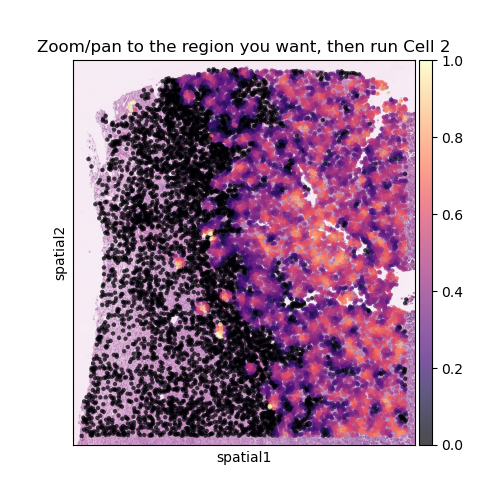

In [43]:
# Cell 1 — draw normally, then zoom/pan with the toolbar
fig, ax = plt.subplots(figsize=(5,5))
sq.pl.spatial_scatter(
    lr, color=pair, size=0.5, cmap="magma",
    library_id=lib_id, img_res_key="hires",
    crop_coord=crop, alpha=0.7, fig=fig, ax=ax, return_ax=False
)
ax.invert_yaxis()
ax.set_title("Zoom/pan to the region you want, then run Cell 2")


In [44]:
# Cell 2 — subset to the current axes view
coords = lr.obsm["spatial"]
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()

# account for possible inverted y
xmin, xmax = min(x0, x1), max(x0, x1)
ymin, ymax = min(y0, y1), max(y0, y1)

mask = (coords[:,0] >= xmin) & (coords[:,0] <= xmax) & \
       (coords[:,1] >= ymin) & (coords[:,1] <= ymax)

print("Selected:", mask.sum(), "/", len(mask))
selected_ids = lr.obs.index[mask]


Selected: 0 / 12667


In [47]:
print("coords (data) x:[", lr.obsm["spatial"][:,0].min(), ",", lr.obsm["spatial"][:,0].max(), "]")
print("coords (data) y:[", lr.obsm["spatial"][:,1].min(), ",", lr.obsm["spatial"][:,1].max(), "]")
print("ax lims x:", ax.get_xlim(), " y:", ax.get_ylim())


coords (data) x:[ 6349.939328643585 , 10062.711661063548 ]
coords (data) y:[ 1803.6789658277141 , 6003.111963519815 ]
ax lims x: (711.0714055810657, 2882.4999446528304)  y: (1499.4999682818147, 3113.7856585127975)


In [48]:
lib = lib_id
res = "hires"  # matches img_res_key
sf = ST_sample.uns["spatial"][lib]["scalefactors"][f"tissue_{res}_scalef"]
print("scale factor:", sf)

coords_full = lr.obsm["spatial"]                # full-res pixels (your big numbers)
coords_plot = coords_full * sf                   # rescaled to hires image space

# sanity: now these should overlap ax limits
print("scaled x:", coords_plot[:,0].min(), coords_plot[:,0].max())
print("scaled y:", coords_plot[:,1].min(), coords_plot[:,1].max())
print("ax lims :", ax.get_xlim(), ax.get_ylim())


scale factor: 1.0
scaled x: 6349.939328643585 10062.711661063548
scaled y: 1803.6789658277141 6003.111963519815
ax lims : (711.0714055810657, 2882.4999446528304) (1499.4999682818147, 3113.7856585127975)


In [50]:
print("x data:", lr.obsm["spatial"][:,0].min(), lr.obsm["spatial"][:,0].max())
print("ax lims:", ax.get_xlim())


x data: 6349.939328643585 10062.711661063548
ax lims: (0.0, 1.0)


/tmp/ipykernel_9441/1977042456.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


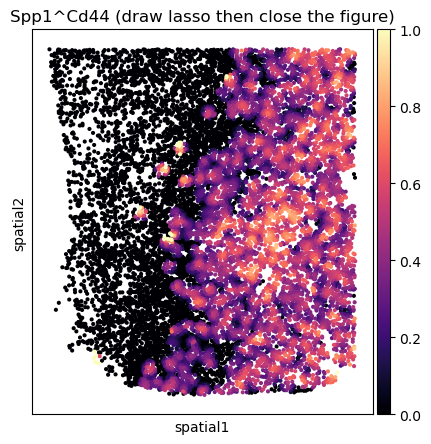

In [71]:
selected = np.zeros(coords.shape[0], dtype=bool)

fig, ax = plt.subplots(figsize=(5,5))
sc.pl.spatial(lr, color=[pair], size=0.5, cmap="magma",
              library_id=lib_id, img_key=None, show=False, ax=ax)
ax.set_title(f"{pair} (draw lasso then close the figure)")

def onselect(verts):
    global selected
    path = Path(verts)
    selected = path.contains_points(coords)

lasso = LassoSelector(ax, onselect)
plt.show()

# After closing the window, `selected` is your lasso mask
if not selected.any():
    # If you didn't draw, treat all as selected
    selected = np.ones(coords.shape[0], dtype=bool)


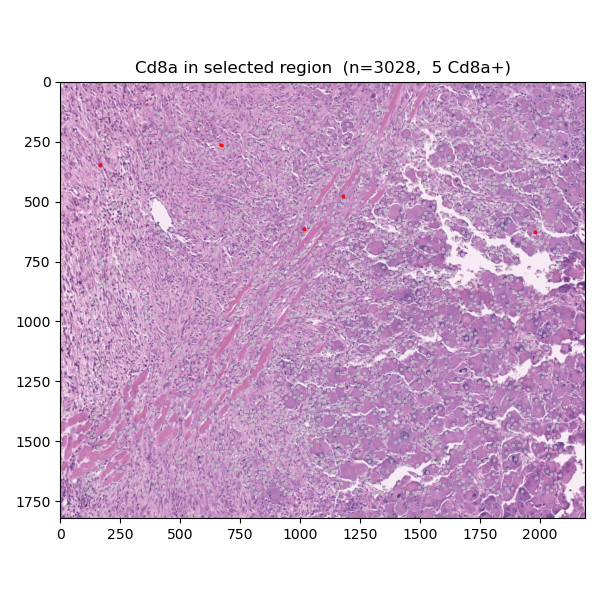

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

# --- inputs (from your session) ---
lib = "F07839"
img  = ST_sample.uns["spatial"][lib]["images"]["hires"]   # full-res H×W[×3]
H, W = img.shape[:2]
coords_all = np.asarray(lr.obsm["spatial"])               # full-res pixel coords (n,2)
mask = state["sel"].copy()                                # boolean mask for selected cells

# --- pick the gene + expression vector aligned to lr.obs.index ---
gene = "Cd8a"#"Klrd1"   # case-sensitive
assert gene in ST_sample.var_names, f"{gene} not in var_names"
# pull expression using lr.obs.index to align rows
idx = ST_sample.obs.index.get_indexer(lr.obs.index)
x = ST_sample.X[idx, ST_sample.var_names.get_loc(gene)]
x = x.toarray().ravel() if sp.issparse(x) else np.asarray(x).ravel()

# define "expressing" rule (tweak threshold as you like)
cd8a_pos_all = x > 0

# --- crop bounds from selected cells (+ padding) ---
coords_sel = coords_all[mask]
pad = 100  # pixels of context
xmin = max(0,      int(np.floor(coords_sel[:,0].min()) - pad))
xmax = min(W,      int(np.ceil (coords_sel[:,0].max()) + pad))
ymin = max(0,      int(np.floor(coords_sel[:,1].min()) - pad))
ymax = min(H,      int(np.ceil (coords_sel[:,1].max()) + pad))

# crop image
img_crop = img[ymin:ymax, xmin:xmax]
h, w = img_crop.shape[:2]

# adjust coordinates so the crop’s origin is (0,0)
coords_sel_adj = coords_sel.copy()
coords_sel_adj[:,0] -= xmin
coords_sel_adj[:,1] -= ymin

# split selected cells by Cd8a status
cd8a_pos_sel = cd8a_pos_all[mask]
cd8a_neg_sel = ~cd8a_pos_sel

# --- plot ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_crop, origin="upper", extent=(0, w, h, 0))
# Cd8a- (grey dots behind)
ax.scatter(coords_sel_adj[cd8a_neg_sel,0], coords_sel_adj[cd8a_neg_sel,1],
           s=6, c="lightgrey", alpha=0.6, linewidths=0)
# Cd8a+ (bright overlay)
ax.scatter(coords_sel_adj[cd8a_pos_sel,0], coords_sel_adj[cd8a_pos_sel,1],
           s=8, c="red", alpha=0.9, linewidths=0)
ax.set_xlim(0, w); ax.set_ylim(h, 0)
ax.set_title(f"{gene} in selected region  (n={mask.sum()},  {cd8a_pos_sel.sum()} {gene}+)")
plt.tight_layout()

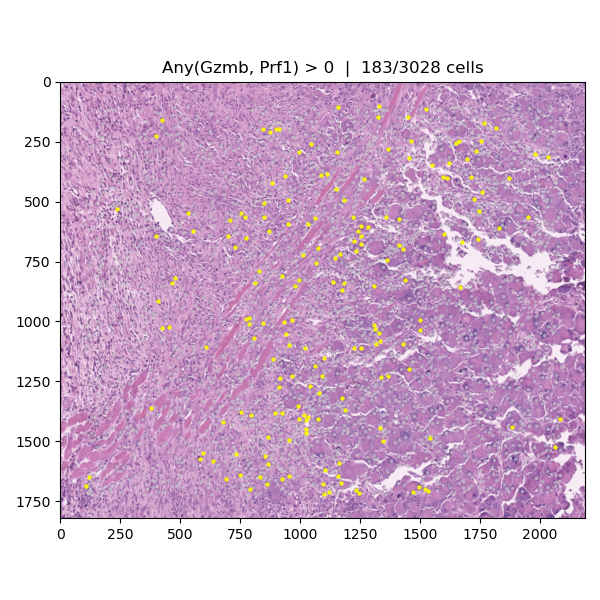

In [73]:
# If you already computed crop bounds earlier, reuse them; otherwise:
coords_sel = coords_all[mask]
pad = 100
xmin = max(0, int(np.floor(coords_sel[:,0].min()) - pad))
xmax = min(W, int(np.ceil (coords_sel[:,0].max()) + pad))
ymin = max(0, int(np.floor(coords_sel[:,1].min()) - pad))
ymax = min(H, int(np.ceil (coords_sel[:,1].max()) + pad))

img_crop = img[ymin:ymax, xmin:xmax]
h, w = img_crop.shape[:2]

coords_sel_adj = coords_sel.copy()
coords_sel_adj[:,0] -= xmin
coords_sel_adj[:,1] -= ymin

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_crop, origin="upper", extent=(0, w, h, 0))

# negatives (behind)
ax.scatter(coords_sel_adj[~any_pos_sel,0], coords_sel_adj[~any_pos_sel,1],
           s=6, c="lightgrey", alpha=0.6, linewidths=0)

# ANY-positive across your gene set (highlight)
ax.scatter(coords_sel_adj[any_pos_sel,0], coords_sel_adj[any_pos_sel,1],
           s=10, c="yellow", alpha=0.9, linewidths=0)

ax.set_xlim(0, w); ax.set_ylim(h, 0)
ax.set_title(f"Any({', '.join(genes_found)}) > {thr}  |  "
             f"{any_pos_sel.sum()}/{mask.sum()} cells")
plt.tight_layout()


In [ ]:
# optional: save
out_png = f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/overlays/{lib}_{gene}_crop.png"
fig.savefig(out_png, dpi=300)
print("Saved:", out_png)

# if you also want the crop bounds for reproducibility:
crop_bounds = {"xmin": xmin, "xmax": xmax, "ymin": ymin, "ymax": ymax, "pad": pad}
print("Crop bounds:", crop_bounds)

In [62]:
import numpy as np, scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

# --- 0) Inputs from your last cell ---
sel_mask   = state["sel"].copy()
coords_full = np.asarray(lr.obsm["spatial"])          # full-res pixels (all cells)
coords_sel  = coords_full[sel_mask]
vals_lr_all = lr[:, pair].X
vals_lr_all = vals_lr_all.toarray().ravel() if sp.issparse(vals_lr_all) else np.asarray(vals_lr_all).ravel()
vals_lr_sel = vals_lr_all[sel_mask]

adata_sel = ST_sample[ST_sample.obs.index.isin(lr.obs.index[sel_mask])].copy()
print("Selected cells:", sel_mask.sum())

# --- 1) Define gene sets (mouse symbols) and score them ---
cd8_genes = ["Cd8a"]#,"Cd8b1","Lck","Trac","Cxcr6"]               # tweak as you like
nk_genes  = ["Nkg7","Klrk1","Klrb1c","Prf1","Gzmb","Xcl1"]      # tweak as you like

def mean_log1p_expr(adata, genes):
    genes = [g for g in genes if g in adata.var_names]
    if not genes:
        return np.zeros(adata.n_obs)
    X = adata[:, genes].X
    X = X.toarray() if sp.issparse(X) else np.asarray(X)
    return np.log1p(X).mean(axis=1)

cd8_score = mean_log1p_expr(adata_sel, cd8_genes)
nk_score  = mean_log1p_expr(adata_sel, nk_genes)

# thresholds (you can switch to absolute thresholds if you prefer)
cd8_high = cd8_score >= np.quantile(cd8_score, 0.75)
nk_high  = nk_score  >= np.quantile(nk_score,  0.75)
lr_high  = vals_lr_sel >= np.quantile(vals_lr_sel, 0.75)

print(f"CD8+ high: {cd8_high.sum()} | NK high: {nk_high.sum()} | {pair} high: {lr_high.sum()}")

Selected cells: 2556
CD8+ high: 2556 | NK high: 2556 | Spp1^Cd44 high: 639


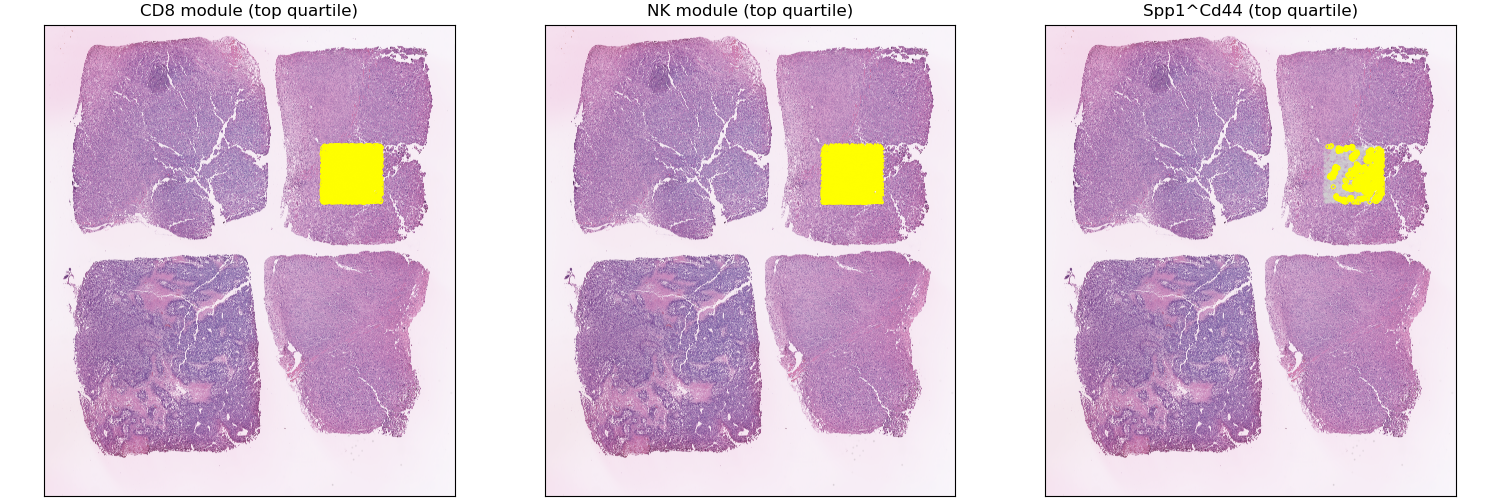

In [63]:
# --- 2) Plot overlays (full-res background kept) ---
H, W = ST_sample.uns["spatial"][lib]["images"]["hires"].shape[:2]
img   = ST_sample.uns["spatial"][lib]["images"]["hires"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

titles = ["CD8 module (top quartile)", "NK module (top quartile)", f"{pair} (top quartile)"]
masks  = [cd8_high, nk_high, lr_high]
markers= ["o", "^", "o"]
edges  = ["none","none","k"]  # black edge for LR-high

for ax, title, m, marker, ec in zip(axes, titles, masks, markers, edges):
    ax.imshow(img, origin="upper", extent=(0, W, H, 0))
    # faded all selected cells in gray for context
    ax.scatter(coords_sel[:,0], coords_sel[:,1], s=3, c="lightgray", alpha=0.35, linewidths=0)
    # highlight positives
    if m.any():
        ax.scatter(coords_sel[m,0], coords_sel[m,1], s=8, c=None, facecolors="none",
                   edgecolors="yellow" if title!=""+"" else "yellow", linewidths=0.8, marker=marker)
        # (swap to solid color by replacing facecolors="none" with a color, e.g. 'dodgerblue')
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

plt.show()

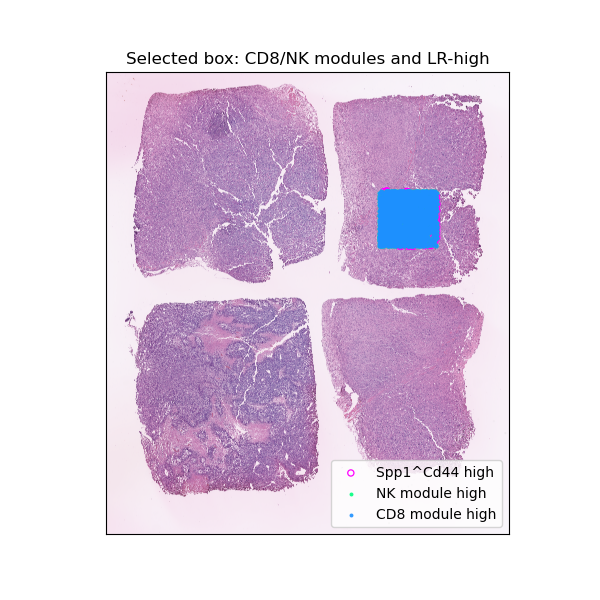

In [61]:
# --- 3) (Optional) One combined panel with color codes ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img, origin="upper", extent=(0, W, H, 0))
# draw order: light gray context, then LR-high ring, NK, CD8
ax.scatter(coords_sel[:,0], coords_sel[:,1], s=3, c="lightgray", alpha=0.25, linewidths=0)
ax.scatter(coords_sel[lr_high,0],  coords_sel[lr_high,1],  s=20, facecolors="none", edgecolors="magenta", linewidths=0.9, label=f"{pair} high")
ax.scatter(coords_sel[nk_high,0],  coords_sel[nk_high,1],  s=8,  c="springgreen", alpha=0.9, linewidths=0, label="NK module high")
ax.scatter(coords_sel[cd8_high,0], coords_sel[cd8_high,1], s=8,  c="dodgerblue", alpha=0.9, linewidths=0, label="CD8 module high")
ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Selected box: CD8/NK modules and LR-high")
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.8)
plt.show()

In [ ]:
# --- 4) Save (optional) ---
outdir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/overlays")
outdir.mkdir(parents=True, exist_ok=True)
(fig).savefig(outdir / f"{lib}_{pair}_selected_overlay.png", dpi=300)